In [1]:
sample_sizes = [10, 30, 100]

X̄ = sample mean

μ = population mean

σ² = population variance

n = sample size

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

In [3]:
np.random.seed(42)

In [4]:
exponential_population = np.random.exponential(scale=2, size=100000)

In [6]:
uniform_population = np.random.uniform(low=0, high=10, size=100000)

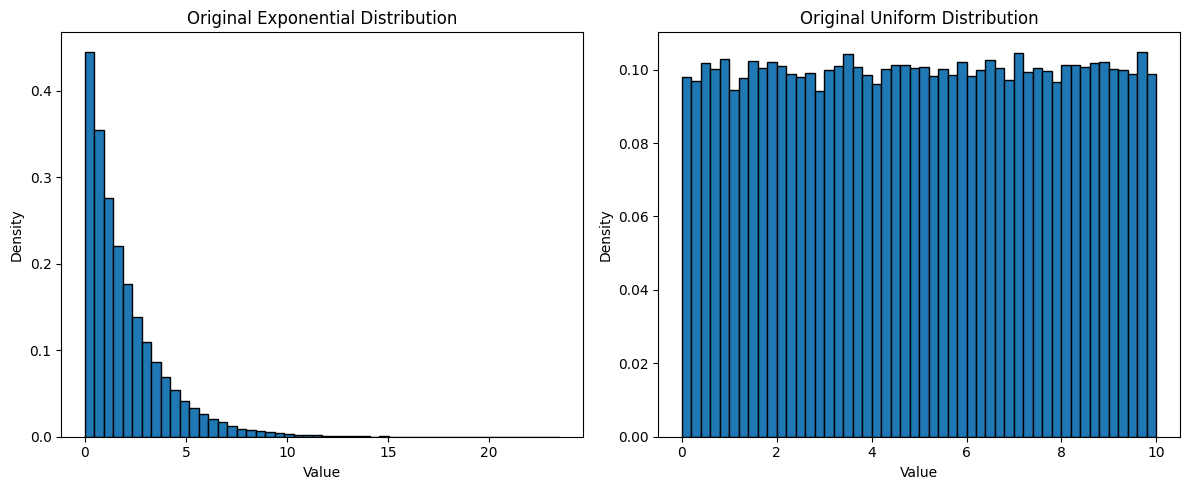

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(exponential_population, bins=50, density=True, edgecolor='black')
plt.title("Original Exponential Distribution")
plt.xlabel("Value")
plt.ylabel("Density")

plt.subplot(1, 2, 2)
plt.hist(uniform_population, bins=50, density=True, edgecolor='black')
plt.title("Original Uniform Distribution")
plt.xlabel("Value")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

In [8]:
def generate_sample_means(population, sample_size, number_of_samples=5000):
    sample_means = []

    for i in range(number_of_samples):
        sample = np.random.choice(population, size=sample_size, replace=True)
        sample_mean = np.mean(sample)
        sample_means.append(sample_mean)

    return np.array(sample_means)

In [9]:
def plot_clt_results(population, distribution_name, sample_sizes):
    for n in sample_sizes:
        sample_means = generate_sample_means(population, sample_size=n)

        plt.figure(figsize=(12, 5))

        # Histogram
        plt.subplot(1, 2, 1)
        plt.hist(sample_means, bins=40, density=True, edgecolor='black')
        plt.title(f"{distribution_name}: Sampling Distribution of Means\nSample Size = {n}")
        plt.xlabel("Sample Mean")
        plt.ylabel("Density")

        # QQ-Plot
        plt.subplot(1, 2, 2)
        stats.probplot(sample_means, dist="norm", plot=plt)
        plt.title(f"QQ-Plot for Sample Means\nSample Size = {n}")

        plt.tight_layout()
        plt.show()

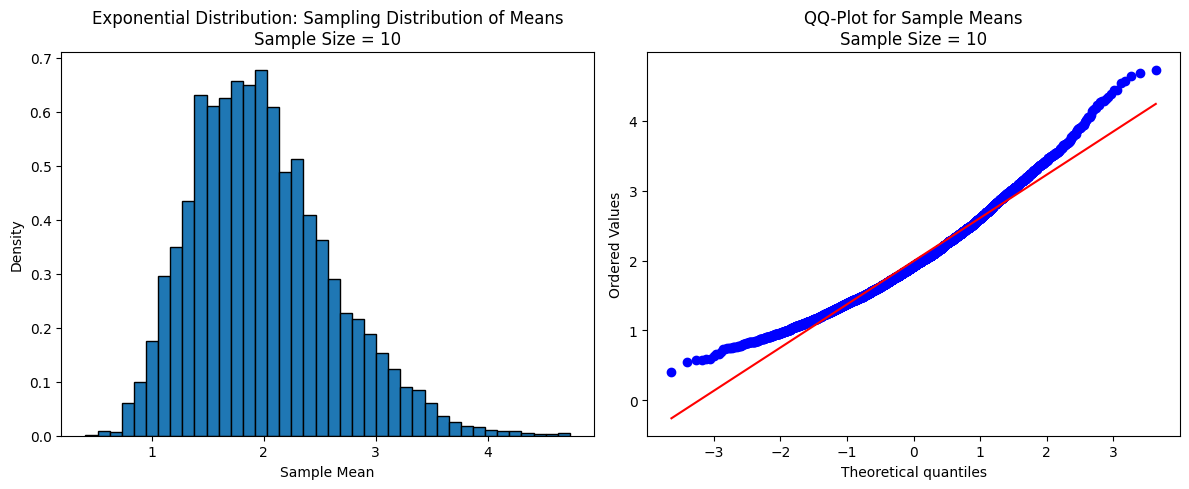

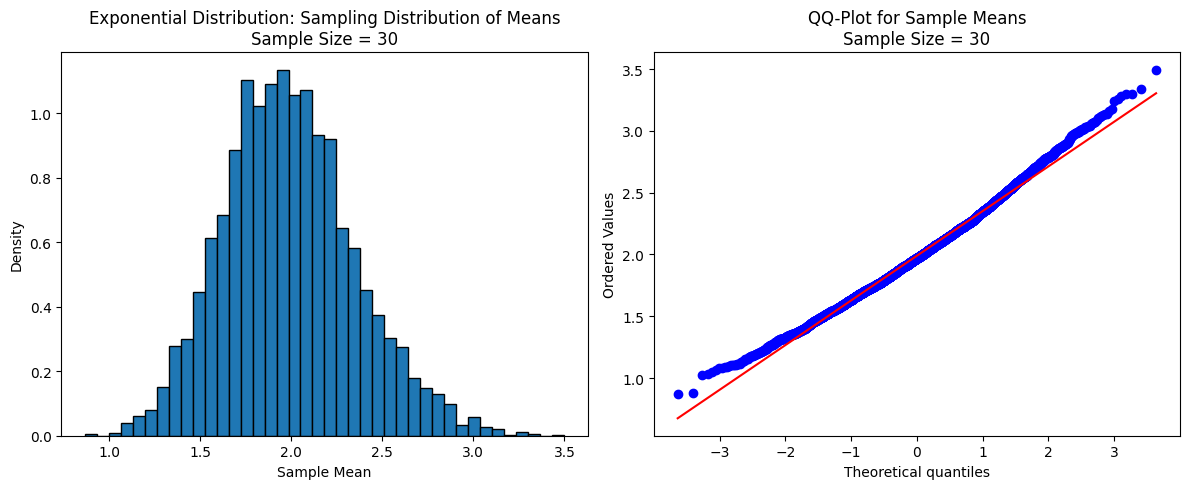

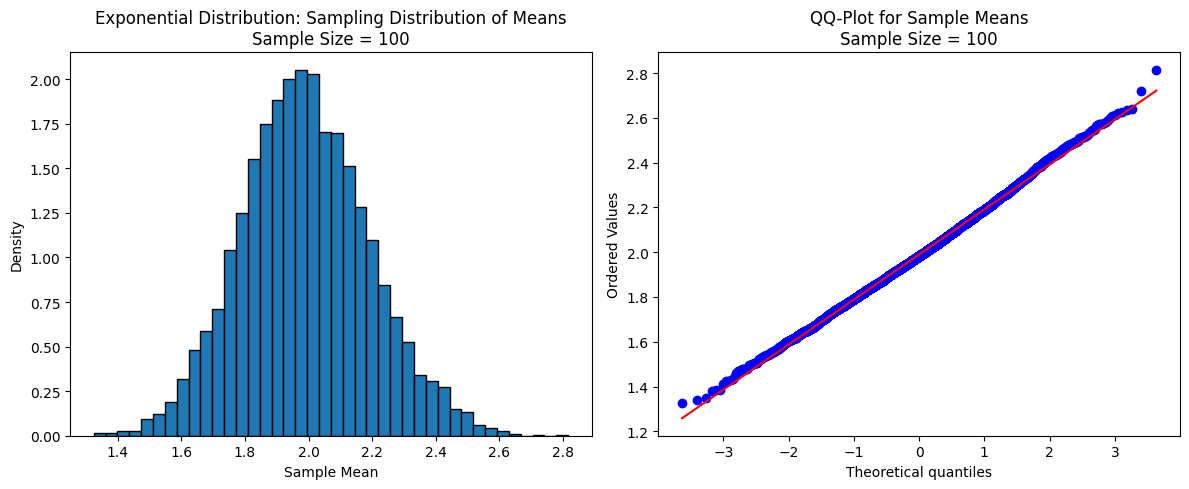

In [10]:
sample_sizes = [10, 30, 100]

plot_clt_results(
    population=exponential_population,
    distribution_name="Exponential Distribution",
    sample_sizes=sample_sizes
)

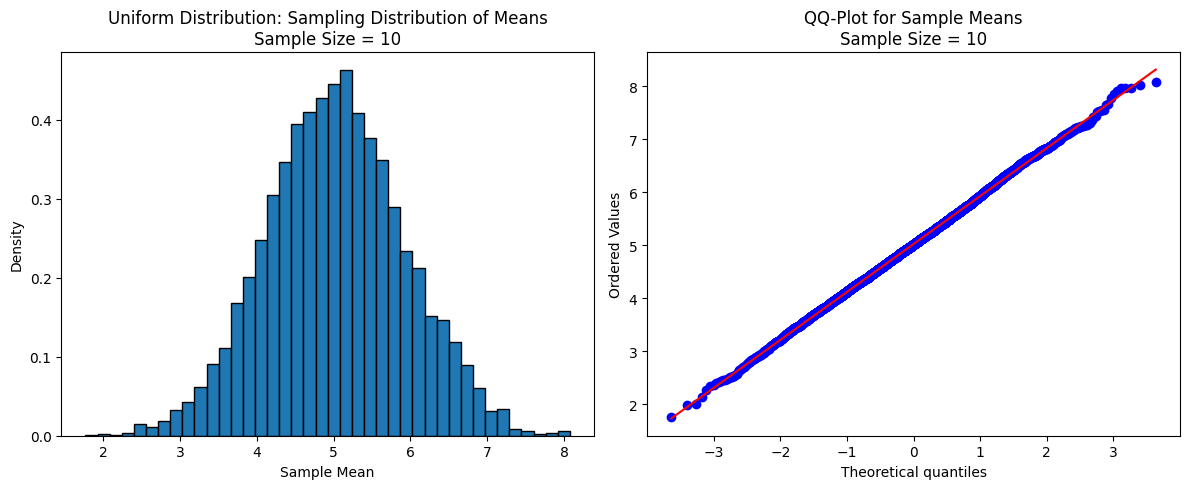

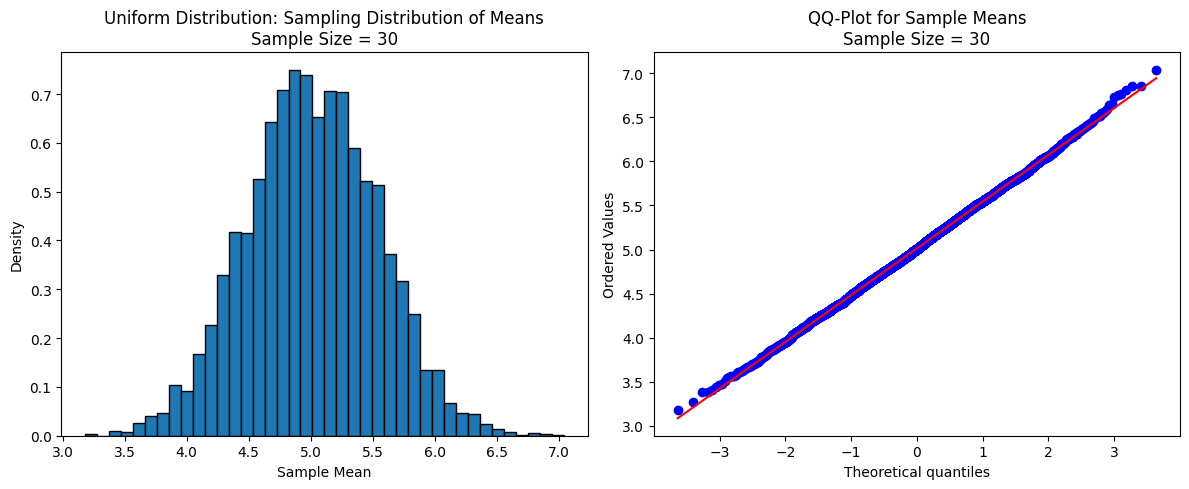

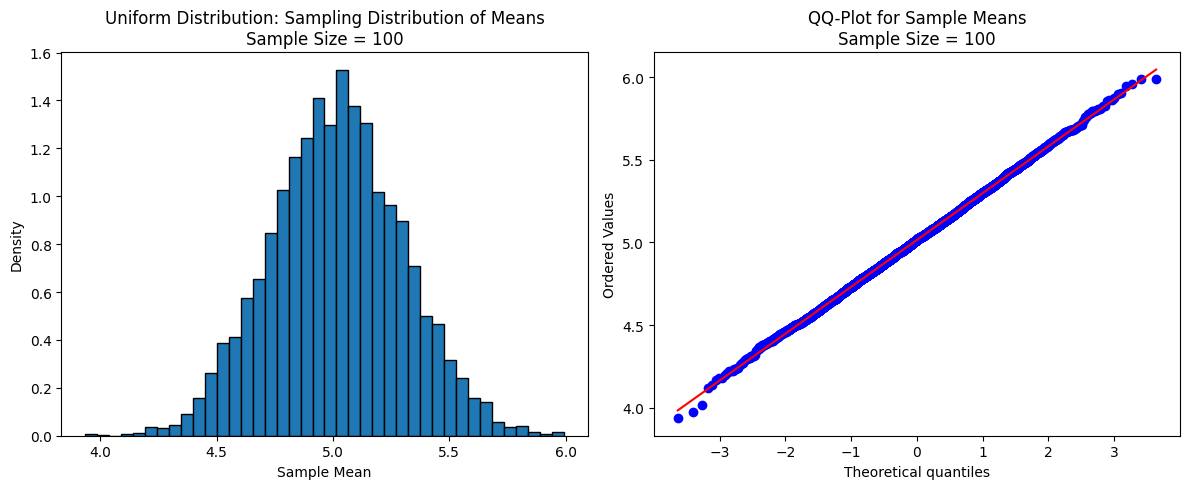

In [11]:
plot_clt_results(
    population=uniform_population,
    distribution_name="Uniform Distribution",
    sample_sizes=sample_sizes
)

In [12]:
def calculate_statistics(population, distribution_name, sample_sizes):
    results = []

    for n in sample_sizes:
        sample_means = generate_sample_means(population, sample_size=n)

        results.append({
            "Distribution": distribution_name,
            "Sample Size": n,
            "Mean of Sample Means": np.mean(sample_means),
            "Standard Deviation": np.std(sample_means),
            "Skewness": stats.skew(sample_means),
            "Excess Kurtosis": stats.kurtosis(sample_means)
        })

    return results

In [13]:
exponential_stats = calculate_statistics(
    exponential_population,
    "Exponential",
    sample_sizes
)

uniform_stats = calculate_statistics(
    uniform_population,
    "Uniform",
    sample_sizes
)

all_results = exponential_stats + uniform_stats

results_df = pd.DataFrame(all_results)

results_df

,Distribution,Sample Size,Mean of Sample Means,Standard Deviation,Skewness,Excess Kurtosis
0,Exponential,10,1.998036,0.632049,0.645121,0.586866
1,Exponential,30,1.986568,0.363784,0.333926,-0.006210
2,Exponential,100,1.994395,0.197614,0.189758,-0.020026
3,Uniform,10,5.021826,0.924419,0.020824,-0.078219
4,Uniform,30,5.014620,0.521328,0.016594,-0.043848
5,Uniform,100,5.011219,0.283578,0.035724,-0.067227


In [14]:
def theoretical_comparison(population, distribution_name, sample_sizes):
    population_mean = np.mean(population)
    population_std = np.std(population)

    comparison_results = []

    for n in sample_sizes:
        sample_means = generate_sample_means(population, sample_size=n)

        empirical_std = np.std(sample_means)
        theoretical_std = population_std / np.sqrt(n)

        comparison_results.append({
            "Distribution": distribution_name,
            "Sample Size": n,
            "Population Mean": population_mean,
            "Mean of Sample Means": np.mean(sample_means),
            "Empirical Std of Sample Means": empirical_std,
            "Theoretical Standard Error": theoretical_std
        })

    return comparison_results

In [15]:
exp_comparison = theoretical_comparison(
    exponential_population,
    "Exponential",
    sample_sizes
)

uni_comparison = theoretical_comparison(
    uniform_population,
    "Uniform",
    sample_sizes
)

comparison_df = pd.DataFrame(exp_comparison + uni_comparison)

comparison_df

,Distribution,Sample Size,Population Mean,Mean of Sample Means,Empirical Std of Sample Means,Theoretical Standard Error
0,Exponential,10,1.991940,1.998275,0.626625,0.628009
1,Exponential,30,1.991940,1.981793,0.361638,0.362581
2,Exponential,100,1.991940,1.990941,0.194099,0.198594
3,Uniform,10,5.013301,5.027488,0.906182,0.912919
4,Uniform,30,5.013301,5.009329,0.525786,0.527074
5,Uniform,100,5.013301,5.008853,0.287964,0.288690
